<a href="https://colab.research.google.com/github/devika-na/flush-intelligence/blob/main/flush_intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install librosa soundfile

In [2]:
from google.colab import files

uploaded = files.upload()

Saving skibidi toilet flush sound effect #skibiditoilet [yhujujc0x0U] - Copy.mp3 to skibidi toilet flush sound effect #skibiditoilet [yhujujc0x0U] - Copy.mp3


In [3]:
import librosa

filename = list(uploaded.keys())[0]

y, sr = librosa.load(filename, sr=None)

print("File:", filename)
print("Sample rate:", sr, "Hz")
print("Duration:", round(len(y) / sr, 2), "seconds")
print("Audio samples:", len(y))

File: skibidi toilet flush sound effect #skibiditoilet [yhujujc0x0U] - Copy.mp3
Sample rate: 44100 Hz
Duration: 4.32 seconds
Audio samples: 190464


In [4]:
from IPython.display import Audio, display

display(Audio(y, rate=sr))

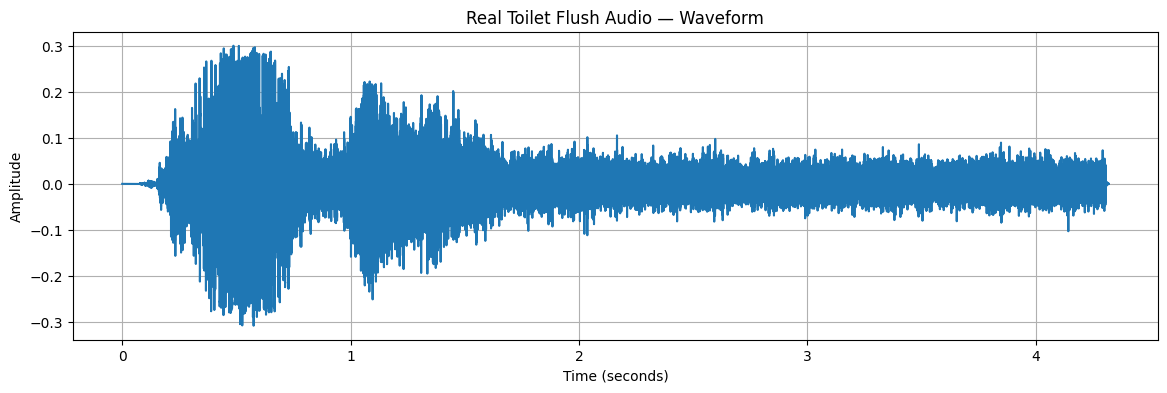

In [5]:
import matplotlib.pyplot as plt
import numpy as np

time = np.arange(len(y)) / sr

plt.figure(figsize=(14, 4))
plt.plot(time, y)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Real Toilet Flush Audio — Waveform")
plt.grid(True)
plt.show()

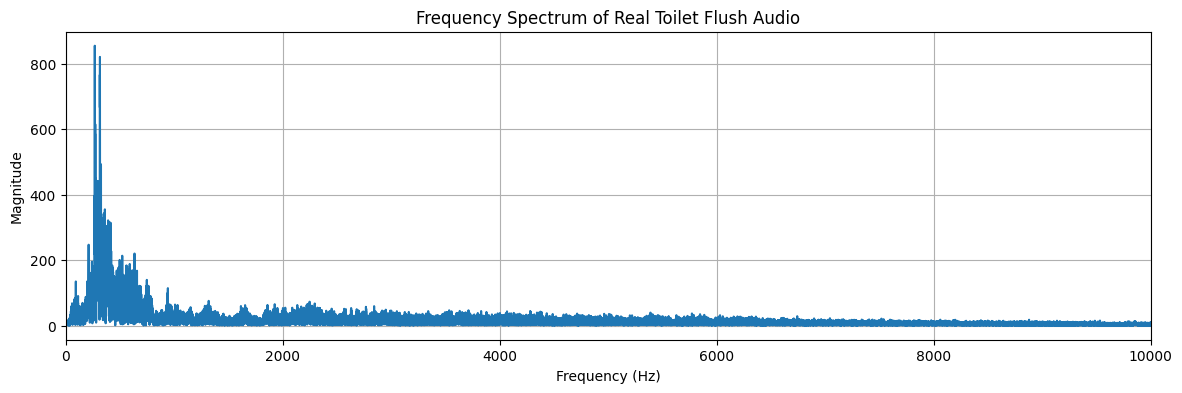

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate frequency spectrum
spectrum = np.abs(np.fft.rfft(y))
frequencies = np.fft.rfftfreq(len(y), 1/sr)

# Plot
plt.figure(figsize=(14, 4))
plt.plot(frequencies, spectrum)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Frequency Spectrum of Real Toilet Flush Audio")
plt.xlim(0, 10000)
plt.grid(True)
plt.show()

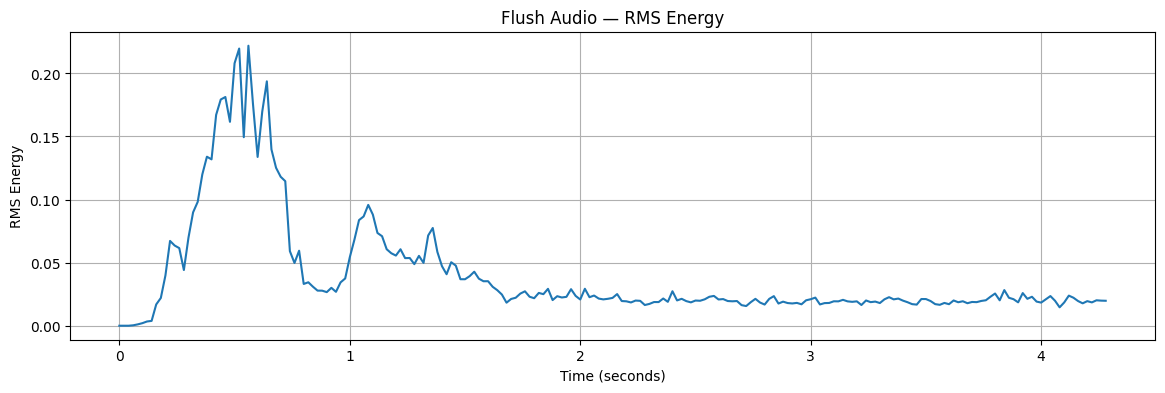

RMS windows: 215
Maximum RMS: 0.2219
Average RMS: 0.0402


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Window size: 20 milliseconds
window_size = int(0.02 * sr)

rms = []

for i in range(0, len(y) - window_size, window_size):
    window = y[i:i + window_size]
    energy = np.sqrt(np.mean(window ** 2))
    rms.append(energy)

rms = np.array(rms)

# Time axis for RMS
rms_time = np.arange(len(rms)) * window_size / sr

plt.figure(figsize=(14, 4))
plt.plot(rms_time, rms)
plt.xlabel("Time (seconds)")
plt.ylabel("RMS Energy")
plt.title("Flush Audio — RMS Energy")
plt.grid(True)
plt.show()

print("RMS windows:", len(rms))
print("Maximum RMS:", round(np.max(rms), 4))
print("Average RMS:", round(np.mean(rms), 4))

In [8]:
# Find the strongest frequencies

peak_indices = np.argsort(spectrum)[-10:][::-1]

print("Top 10 dominant frequencies:")
for i in peak_indices:
    print(f"{frequencies[i]:.1f} Hz")

Top 10 dominant frequencies:
268.4 Hz
268.6 Hz
316.1 Hz
268.1 Hz
315.8 Hz
315.1 Hz
267.9 Hz
314.9 Hz
316.3 Hz
268.8 Hz
